<a href="https://colab.research.google.com/github/hanna04107-wq/CPI-PREDICTION-USING-MACROECONOMIC-INDICATORS-AND-MACHINE-LEARNING-MODEL/blob/main/TRIAL_FYP_CODING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **ANALISIS DESKRIPTIF**

In [ ]:
import matplotlib.pyplot as plt
import numpy as mp
import pandas as pd

In [ ]:
df_data   = pd.read_csv("/content/Final_Macroeconomic_Dataset_2013_2026_Jan.csv")

In [ ]:
df_data.head()

,Date,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate
0,2013-01-01,2013,1,105.9,3.0390,1375858.0,3.0,107.9,3.4
1,2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0
2,2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2
3,2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0
4,2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2


In [ ]:
df_data.describe()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate
count,157.000000,157.000000,157.000000,157.000000,1.570000e+02,157.000000,157.000000,157.000000
mean,2019.044586,6.464968,121.282803,4.086168,1.939963e+06,2.816879,110.154777,3.476433
std,3.783134,3.479848,8.287225,0.438620,3.558274e+05,0.497898,6.764997,0.548908
min,2013.000000,1.000000,105.900000,3.016800,1.375858e+06,1.750000,99.000000,2.600000
25%,2016.000000,3.000000,114.800000,4.026900,1.611143e+06,2.750000,105.000000,3.200000
50%,2019.000000,6.000000,120.900000,4.177600,1.913308e+06,3.000000,108.300000,3.300000
75%,2022.000000,9.000000,128.600000,4.348100,2.257146e+06,3.250000,116.300000,3.500000
max,2026.000000,12.000000,135.700000,4.772300,2.591322e+06,3.250000,124.100000,5.300000


In [ ]:
df_data.dtypes

,0
Date,object
Year,int64
Month,int64
CPI_Index,float64
USD_Avg,float64
M3_Total,float64
OPR_Rate,float64
PPI_Index,float64
Unemployment_Rate,float64


In [ ]:
# 1. Tukar Format Date
# Gantikan 'Date' dengan nama kolum tarikh sebenar dalam CSV
df_data['Date'] = pd.to_datetime(df_data['Date'])
df_data.set_index('Date', inplace=True)

In [ ]:
df_data.dtypes

,0
Year,int64
Month,int64
CPI_Index,float64
USD_Avg,float64
M3_Total,float64
OPR_Rate,float64
PPI_Index,float64
Unemployment_Rate,float64


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2013-01-01 to 2026-01-01
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               157 non-null    int64  
 1   Month              157 non-null    int64  
 2   CPI_Index          157 non-null    float64
 3   USD_Avg            157 non-null    float64
 4   M3_Total           157 non-null    float64
 5   OPR_Rate           157 non-null    float64
 6   PPI_Index          157 non-null    float64
 7   Unemployment_Rate  157 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 11.0 KB


###**PLOT UNTUK MENYEMAK VARIANS**

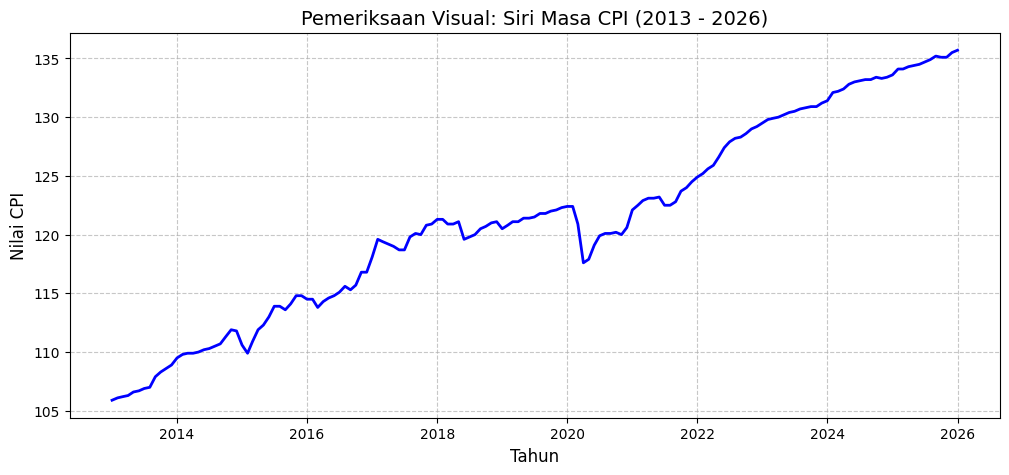

In [ ]:
#Plot data asal untuk menyemak varians
plt.figure(figsize=(12, 5))
plt.plot(df_data.index, df_data['CPI_Index'], color='blue', linewidth=2)
plt.title('Pemeriksaan Visual: Siri Masa CPI (2013 - 2026)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai CPI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Tidak perlu buat transformasi log kerana saiz "zig-zag" agak konsisten.
Oleh itu, varians siri masa CPI dianggap stabil secara semula jadi kejatuhan mendadak (titik terendah selepas trend menaik) berlaku tepat pada awal tahun 2020. Ini bertepatan dengan permulaan pandemik COVID-19 dan pelaksanaan Perintah Kawalan Pergerakan (PKP) di Malaysia yang menjejaskan rantaian bekalan dan perbelanjaan pengguna.

###**UJIAN KEPEGUNAN**

In [ ]:
from statsmodels.tsa.stattools import kpss
import warnings

# Abaikan amaran kpss untuk output terminal yang bersih
warnings.filterwarnings("ignore")

In [ ]:
#Fungsi untuk semak sama ada Y pegun
def semak_kpss(siri_masa, nama_kolum):
    print(f"--- Ujian KPSS untuk {nama_kolum} ---")
    # Menjalankan ujian KPSS
    kpss_stat, p_value, lags, crit_dict = kpss(siri_masa.dropna(), regression='c')

    print(f'Nilai Statistik KPSS : {kpss_stat:.4f}')
    print(f'Nilai p (p-value)    : {p_value:.4f}')

    if p_value < 0.05:
        print("Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN\n")
        return False
    else:
        print("Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)\n")
        return True


In [ ]:
# 1. Uji CPI Asal
pegun_asal = semak_kpss(df_data['CPI_Index'], 'CPI Asal')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal:
    df_data['CPI_diff'] = df_data['CPI_Index'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['CPI_diff'], 'CPI (Selepas Pembezaan)')

--- Ujian KPSS untuk CPI Asal ---
Nilai Statistik KPSS : 1.7615
Nilai p (p-value)    : 0.0100
Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN

--- Menguji Selepas Pembezaan Pertama ---
--- Ujian KPSS untuk CPI (Selepas Pembezaan) ---
Nilai Statistik KPSS : 0.0649
Nilai p (p-value)    : 0.1000
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



In [ ]:
#Fungsi untuk semak sama ada X pegun
def semak_kpss(siri_masa, var):
    print(f"--- Ujian KPSS untuk {var} ---")
    # Menjalankan ujian KPSS
    kpss_stat, p_value, lags, crit_dict = kpss(siri_masa.dropna(), regression='c')

    print(f'Nilai Statistik KPSS : {kpss_stat:.4f}')
    print(f'Nilai p (p-value)    : {p_value:.4f}')

    if p_value < 0.05:
        print("Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN\n")
        return False
    else:
        print("Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)\n")
        return True

In [ ]:
# 1. Uji OPR_Rate Asal
pegun_asal1 = semak_kpss(df_data['OPR_Rate'], 'OPR Rate')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal1:
    df_data['OPR_Rate_diff'] = df_data['OPR_Rate'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['OPR_Rate_diff'], 'OPR Rate (Selepas Pembezaan)')

--- Ujian KPSS untuk OPR Rate ---
Nilai Statistik KPSS : 0.5014
Nilai p (p-value)    : 0.0414
Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN

--- Menguji Selepas Pembezaan Pertama ---
--- Ujian KPSS untuk OPR Rate (Selepas Pembezaan) ---
Nilai Statistik KPSS : 0.1093
Nilai p (p-value)    : 0.1000
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



In [ ]:
df_data.head()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate,CPI_diff,OPR_Rate_diff
Date,,,,,,,,,,
2013-01-01,2013,1,105.9,3.0390,1375858.0,3.0,107.9,3.4,NaN,NaN
2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0,0.2,0.0
2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2,0.1,0.0
2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0,0.1,0.0
2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2,0.3,0.0


In [ ]:
# 1. Uji USD_Avg Asal
pegun_asal2 = semak_kpss(df_data['USD_Avg'], 'USD_Avg')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal2:
    df_data['USD_Avg_diff'] = df_data['USD_Avg'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['USD_Avg_diff'], 'USD_Avg (Selepas Pembezaan)')

--- Ujian KPSS untuk USD_Avg ---
Nilai Statistik KPSS : 1.1980
Nilai p (p-value)    : 0.0100
Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN

--- Menguji Selepas Pembezaan Pertama ---
--- Ujian KPSS untuk USD_Avg (Selepas Pembezaan) ---
Nilai Statistik KPSS : 0.2991
Nilai p (p-value)    : 0.1000
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



In [ ]:
# 1. Uji M3_Total Asal
pegun_asal3 = semak_kpss(df_data['M3_Total'], 'M3_Total')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal3:
    df_data['M3_Total_diff'] = df_data['M3_Total'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['M3_Total_diff'], 'M3_Total (Selepas Pembezaan)')

--- Ujian KPSS untuk M3_Total ---
Nilai Statistik KPSS : 1.8468
Nilai p (p-value)    : 0.0100
Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN

--- Menguji Selepas Pembezaan Pertama ---
--- Ujian KPSS untuk M3_Total (Selepas Pembezaan) ---
Nilai Statistik KPSS : 0.1348
Nilai p (p-value)    : 0.1000
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



In [ ]:
# 1. Uji PPI_Index Asal
pegun_asal4 = semak_kpss(df_data['PPI_Index'], 'PPI_Index')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal4:
    df_data['PPI_Index_diff'] = df_data['PPI_Index'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['PPI_Index_diff'], 'PPI_Index (Selepas Pembezaan)')

--- Ujian KPSS untuk PPI_Index ---
Nilai Statistik KPSS : 1.0281
Nilai p (p-value)    : 0.0100
Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN

--- Menguji Selepas Pembezaan Pertama ---
--- Ujian KPSS untuk PPI_Index (Selepas Pembezaan) ---
Nilai Statistik KPSS : 0.0925
Nilai p (p-value)    : 0.1000
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



In [ ]:
# 1. Uji Unemployment_Rate Asal
pegun_asal4 = semak_kpss(df_data['Unemployment_Rate'], 'Unemployment_Rate')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal4:
    df_data['Unemployment_Rate'] = df_data['Unemployment_Rate'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['Unemployment_Rate_diff'], 'Unemployment_Rate (Selepas Pembezaan)')

--- Ujian KPSS untuk Unemployment_Rate ---
Nilai Statistik KPSS : 0.3922
Nilai p (p-value)    : 0.0805
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



In [ ]:
df_data.head()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate,CPI_diff,OPR_Rate_diff,USD_Avg_diff,M3_Total_diff,PPI_Index_diff
Date,,,,,,,,,,,,,
2013-01-01,2013,1,105.9,3.0390,1375858.0,3.0,107.9,3.4,NaN,NaN,NaN,NaN,NaN
2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0,0.2,0.0,0.0588,3531.6,1.7
2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2,0.1,0.0,0.0098,12733.3,-1.4
2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0,0.1,0.0,-0.0578,7676.0,-0.9
2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2,0.3,0.0,-0.0330,14833.2,-0.7


In [ ]:
df_bersih = df_data.dropna()

In [ ]:
df_bersih.head()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate,CPI_diff,OPR_Rate_diff,USD_Avg_diff,M3_Total_diff,PPI_Index_diff
Date,,,,,,,,,,,,,
2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0,0.2,0.0,0.0588,3531.6,1.7
2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2,0.1,0.0,0.0098,12733.3,-1.4
2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0,0.1,0.0,-0.0578,7676.0,-0.9
2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2,0.3,0.0,-0.0330,14833.2,-0.7
2013-06-01,2013,6,106.7,3.1489,1414539.9,3.0,107.6,2.8,0.1,0.0,0.1321,-92.2,1.0


Siri masa CPI anda adalah bersepadu pada tahap satu. Ini memberikan justifikasi teori yang sangat kukuh mengapa anda wajib menggunakan siri masa yang telah dibezakan (CPI_diff) untuk model-model garis dasar statistik kelak.

###**UJIAN KORELASI**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1. Senarai pemboleh ubah yang disahkan pegun
senarai_pegun = [
    'OPR_Rate_diff',
    'PPI_Index_diff',
    'Unemployment_Rate', # Mengekalkan yang asal kerana sudah pegun
    'M3_Total_diff',
    'USD_Avg_diff',
    'CPI_diff'           # Sasaran
]

In [ ]:
# 2. Kira matriks korelasi Pearson
matriks_korelasi = df_bersih[senarai_pegun].corr()

In [ ]:
# 3. Susun mengikut kekuatan mutlak terhadap CPI
korelasi_cpi = matriks_korelasi[['CPI_diff']].drop('CPI_diff')
korelasi_cpi.columns = ['Nilai Korelasi (r)']
korelasi_cpi['Kekuatan'] = korelasi_cpi['Nilai Korelasi (r)'].abs()
korelasi_tersusun = korelasi_cpi.sort_values(by='Kekuatan', ascending=False)

In [ ]:
print("--- SUSUNAN KEKUATAN HUBUNGAN TERHADAP INFLASI (CPI_diff) ---")
print("=" * 60)
print(korelasi_tersusun[['Nilai Korelasi (r)']])
print("=" * 60)

--- SUSUNAN KEKUATAN HUBUNGAN TERHADAP INFLASI (CPI_diff) ---
                   Nilai Korelasi (r)
PPI_Index_diff               0.319116
M3_Total_diff               -0.081085
USD_Avg_diff                -0.079319
OPR_Rate_diff                0.068348
Unemployment_Rate           -0.041817


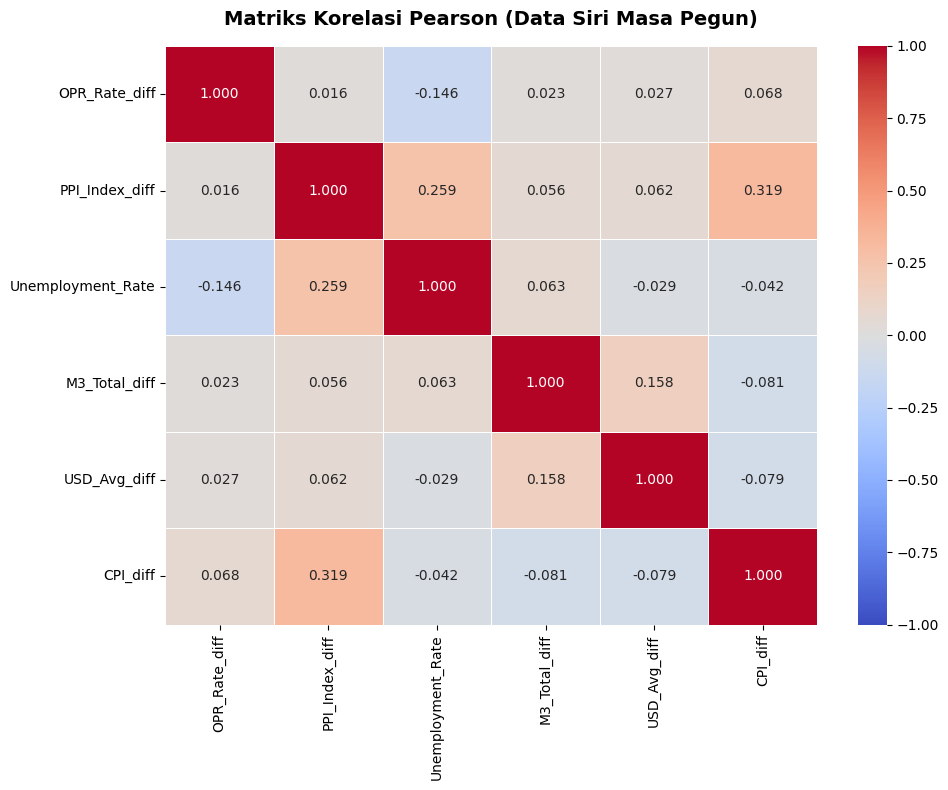

In [ ]:
# 4. Visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi,
            annot=True,
            cmap='coolwarm',
            fmt=".3f",
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title("Matriks Korelasi Pearson (Data Siri Masa Pegun)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

###**UJIAN MULTIKOLINEARITI**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# 1. Senarai X sahaja (Tanpa CPI_diff)
X_vif = df_bersih[[
    'OPR_Rate_diff',
    'PPI_Index_diff',
    'Unemployment_Rate',
    'M3_Total_diff',
    'USD_Avg_diff'
]]

In [ ]:
#2. Tambah pemalar (constant) - Langkah ekonometrik yang wajib untuk VIF
X_vif_dengan_pemalar = sm.add_constant(X_vif)

Mengapa perlu add sm.add_constant : Dalam ekonometrik, model OLS (seperti model garis dasar statistik yang akan anda gunakan nanti) memerlukan titik pintasan paksi-Y (Y-intercept). Pustaka statsmodels sangat ketat dan tidak akan memasukkan pemalar ini secara automatik. Jika kita tidak mengolah data dengan menambah pemalar tersebut sebelum ujian VIF, nilai $R^2$ yang dikira akan menjadi ralat dan memberikan nilai VIF yang palsu.

In [ ]:
# 3. Bina DataFrame untuk menyimpan keputusan
data_vif = pd.DataFrame()
data_vif["Pembolehubah X"] = X_vif_dengan_pemalar.columns

In [ ]:
# 4. Kira nilai VIF untuk setiap pembolehubah
data_vif["Nilai VIF"] = [variance_inflation_factor(X_vif_dengan_pemalar.values, i)
                         for i in range(X_vif_dengan_pemalar.shape[1])]

In [ ]:
# 5. Buang baris 'const' (pemalar) untuk paparan yang bersih
data_vif = data_vif[data_vif['Pembolehubah X'] != 'const']

In [ ]:
# 6. Susun mengikut Nilai VIF tertinggi untuk mudah dianalisis
data_vif = data_vif.sort_values(by="Nilai VIF", ascending=False).reset_index(drop=True)

In [ ]:
print("\nKeputusan Ujian Variance Inflation Factor (VIF):")
print("=" * 60)
print(data_vif)
print("=" * 60)


Keputusan Ujian Variance Inflation Factor (VIF):
      Pembolehubah X  Nilai VIF
0  Unemployment_Rate   1.104558
1     PPI_Index_diff   1.081443
2      M3_Total_diff   1.032218
3       USD_Avg_diff   1.031909
4      OPR_Rate_diff   1.026235


(VIF < 5): Semua pemboleh ubah X berada pada tahap yang sangat sempurna. Ia langsung tidak bertindih fungsi secara melampau antara satu sama lain.

Disesbabkan semua nilai VIF < 10 , maka tidak perlu membuang mana-mana pemboleh ubah

###**PEMBAHAGIAN DATA - LATIHAN DAN UJIAN**

In [ ]:
df_bersih.head()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate,CPI_diff,OPR_Rate_diff,USD_Avg_diff,M3_Total_diff,PPI_Index_diff
Date,,,,,,,,,,,,,
2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0,0.2,0.0,0.0588,3531.6,1.7
2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2,0.1,0.0,0.0098,12733.3,-1.4
2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0,0.1,0.0,-0.0578,7676.0,-0.9
2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2,0.3,0.0,-0.0330,14833.2,-0.7
2013-06-01,2013,6,106.7,3.1489,1414539.9,3.0,107.6,2.8,0.1,0.0,0.1321,-92.2,1.0


In [ ]:
# 1. TPotong data 80/20 secara kronologi
saiz_latihan = int(len(df_bersih) * 0.8)

In [ ]:
# 2. Tetapkan pembolehubah X dan Y
senarai_x_pegun = ['OPR_Rate_diff','PPI_Index_diff','Unemployment_Rate','M3_Total_diff','USD_Avg_diff']
X_latih = df_bersih[senarai_x_pegun].iloc[:saiz_latihan]
X_uji = df_bersih[senarai_x_pegun].iloc[saiz_latihan:]
y_latih_diff = df_bersih['CPI_diff'].iloc[:saiz_latihan]
y_latih_asal = df_bersih['CPI_Index'].iloc[:saiz_latihan]
y_uji_asal = df_bersih['CPI_Index'].iloc[saiz_latihan:]

In [ ]:
# 3. Menyimpan nilai anchor untuk transformasi songsang (Cumulative Sum) nanti
cpi_terakhir_latihan = y_latih_asal.iloc[-1]

In [ ]:
# Paparkan ringkasan pembahagian untuk rujukan tesis
print(f"--- RINGKASAN PEMBAHAGIAN DATA (80/20) ---")
print(f"Jumlah keseluruhan bulan : {len(df_bersih)} bulan")
print(f"Data Latihan (80%)       : {len(X_latih)} bulan (Dari {X_latih.index[0].date()} hingga {X_latih.index[-1].date()})")
print(f"Data Ujian (20%)         : {len(X_uji)} bulan (Dari {X_uji.index[0].date()} hingga {X_uji.index[-1].date()})")

--- RINGKASAN PEMBAHAGIAN DATA (80/20) ---
Jumlah keseluruhan bulan : 156 bulan
Data Latihan (80%)       : 124 bulan (Dari 2013-02-01 hingga 2023-05-01)
Data Ujian (20%)         : 32 bulan (Dari 2023-06-01 hingga 2026-01-01)


###**MODEL OLS**

In [ ]:
import statsmodels.api as sm
import numpy as np

In [ ]:
# 1. Tambah pemalar (Y-intercept) kepada data latihan dan data ujian
X_latih_ols = sm.add_constant(X_latih)
X_uji_ols = sm.add_constant(X_uji)

Sama seperti ujian VIF tadi, kita wajib menambah pemalar (constant) kepada data latihan X_latih supaya garisan regresi tidak dipaksa bermula dari titik sifar (0,0).

In [ ]:
#2. Inisialisasi dan Latih Model OLS
model_ols = sm.OLS(y_latih_diff, X_latih_ols)
keputusan_ols = model_ols.fit()

In [ ]:
# 3. Paparkan Ringkasan Penuh OLS
print(keputusan_ols.summary())

                            OLS Regression Results                            
Dep. Variable:               CPI_diff   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     4.327
Date:                Tue, 09 Jun 2026   Prob (F-statistic):            0.00119
Time:                        14:03:05   Log-Likelihood:                -94.659
No. Observations:                 124   AIC:                             201.3
Df Residuals:                     118   BIC:                             218.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7153      0.31

1. Ujian F menunjukkan model regresi adalah signifikan secara keseluruhan pada aras keertian 5% (p < 0.05), membuktikan pembolehubah makroekonomi yang dipilih mempunyai keupayaan menerangkan perubahan CPI.
2. Ujian Jarque-Bera menunjukkan sisa ralat tidak tertabur secara normal (p < 0.05). Walau bagaimanapun, mengikut Teorem Had Memusat (CLT), kekangan ini boleh dilonggarkan memandangkan jumlah pemerhatian kajian melebihi 100 sampel (N=124).
3. Nilai Durbin-Watson sebanyak 1.658 (kurang daripada 2.0) mengesahkan kehadiran masalah autokorelasi positif dalam sisa ralat model OLS.

###**RAMALAN & UJIAN DATA UNTUK OLS**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [76]:
# 1. Ramalan pada data ujian
ramalan_ols_diff = keputusan_ols.predict(X_uji_ols)

In [77]:
# 2. Transformasi Songsang
ramalan_ols_index = cpi_terakhir_latihan + np.cumsum(ramalan_ols_diff)

In [78]:
# 3. Menilai Prestasi Model OLS
r2_ols = r2_score(y_uji_asal, ramalan_ols_index)
mae_ols = mean_absolute_error(y_uji_asal, ramalan_ols_index)
rmse_ols = np.sqrt(mean_squared_error(y_uji_asal, ramalan_ols_index))

In [79]:
print("\n" + "="*45)
print(" PRESTASI RAMALAN OLS (INDEKS CPI) ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_ols:.4f}")
print(f" Nilai MAE  : {mae_ols:.4f}")
print(f" Nilai RMSE : {rmse_ols:.4f}")
print("="*45 + "\n")


      PRESTASI RAMALAN OLS (INDEKS CPI)      
 Nilai R-Squared (R2) : 0.7106
 Nilai MAE  : 0.6677
 Nilai RMSE : 0.8609



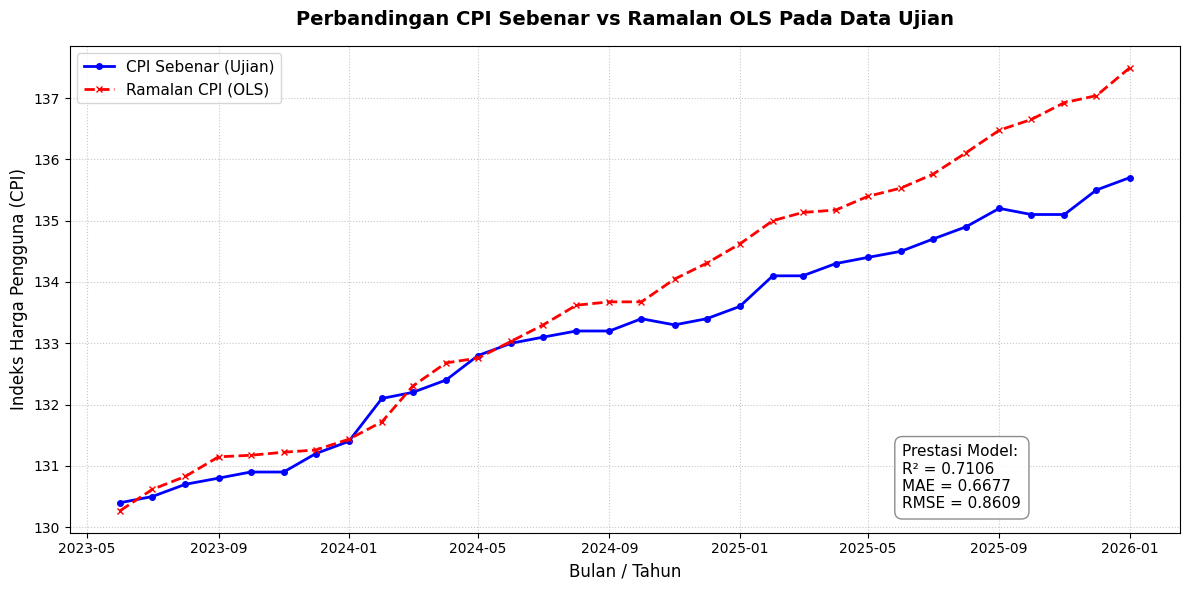

In [81]:
plt.figure(figsize=(12, 6))

# Plot Garisan CPI Sebenar
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Garisan Ramalan OLS
plt.plot(y_uji_asal.index, ramalan_ols_index,
         label='Ramalan CPI (OLS)', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)

# Tetapan Kosmetik
plt.title('Perbandingan CPI Sebenar vs Ramalan OLS Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Memaparkan nilai R2, MAE, dan RMSE di atas graf
kotak_metrik = f'Prestasi Model:\nR² = {r2_ols:.4f}\nMAE = {mae_ols:.4f}\nRMSE = {rmse_ols:.4f}'
plt.text(0.75, 0.05, kotak_metrik,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))
plt.tight_layout()
plt.show()

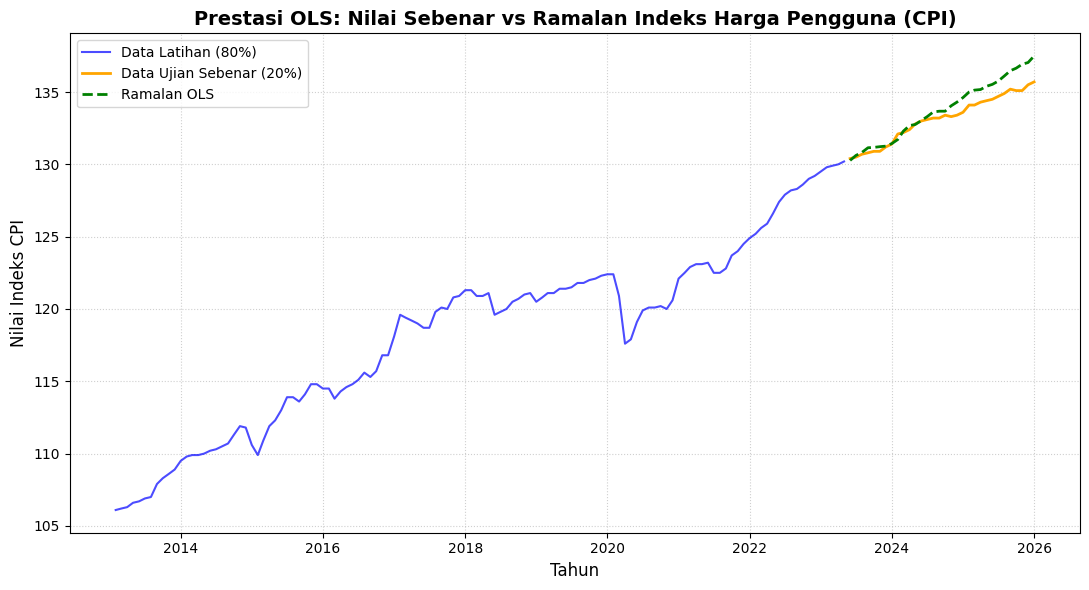

In [83]:
# 9. Plot Graf Perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_ols_index, label='Ramalan OLS', color='green', linestyle='--', linewidth=2)

plt.title('Prestasi OLS: Nilai Sebenar vs Ramalan Indeks Harga Pengguna (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Walaupun jadual perbandingan menunjukkan model OLS mencatatkan ralat MAE (0.6677) yang lebih Tinggi berbanding ARIMA (0.5869)

###**ARIMA**

In [102]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [85]:
best_aic = float("inf")
best_order = None
best_model_arimax = None

In [89]:
# 1. Cari model yang terbaik
for p in range(3):
    for q in range(3):
        try:
            # d ditetapkan sebagai 0 kerana data kita sudah pegun di Fasa 1
            model_terai = SARIMAX(endog=y_latih_diff,
                                  exog=X_latih,
                                  order=(p, 0, q),
                                  trend='c')
            keputusan_terai = model_terai.fit(disp=False)

            if keputusan_terai.aic < best_aic:
                best_aic = keputusan_terai.aic
                best_order = (p, 0, q)
                best_model_arimax = keputusan_terai
        except:
            continue

In [88]:
print(f"\n>> Model Terbaik Yang Dipilih Secara Automatik: ARIMAX{best_order}")
print(f">> Nilai AIC Terbaik: {best_aic:.4f}\n")


>> Model Terbaik Yang Dipilih Secara Automatik: ARIMAX(0, 0, 2)
>> Nilai AIC Terbaik: 199.3992



In [90]:
# 2. Paparkan jadual ringkasan rasmi untuk model terbaik
print(best_model_arimax.summary())

                               SARIMAX Results                                
Dep. Variable:               CPI_diff   No. Observations:                  124
Model:               SARIMAX(0, 0, 2)   Log Likelihood                 -90.700
Date:                Tue, 09 Jun 2026   AIC                            199.399
Time:                        14:30:00   BIC                            224.782
Sample:                    02-01-2013   HQIC                           209.710
                         - 05-01-2023                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0156      0.339      0.046      0.963      -0.649       0.680
OPR_Rate_diff         0.5086      0.458      1.111      0.267      -0.389       1.406
PPI_Index_diff        0.

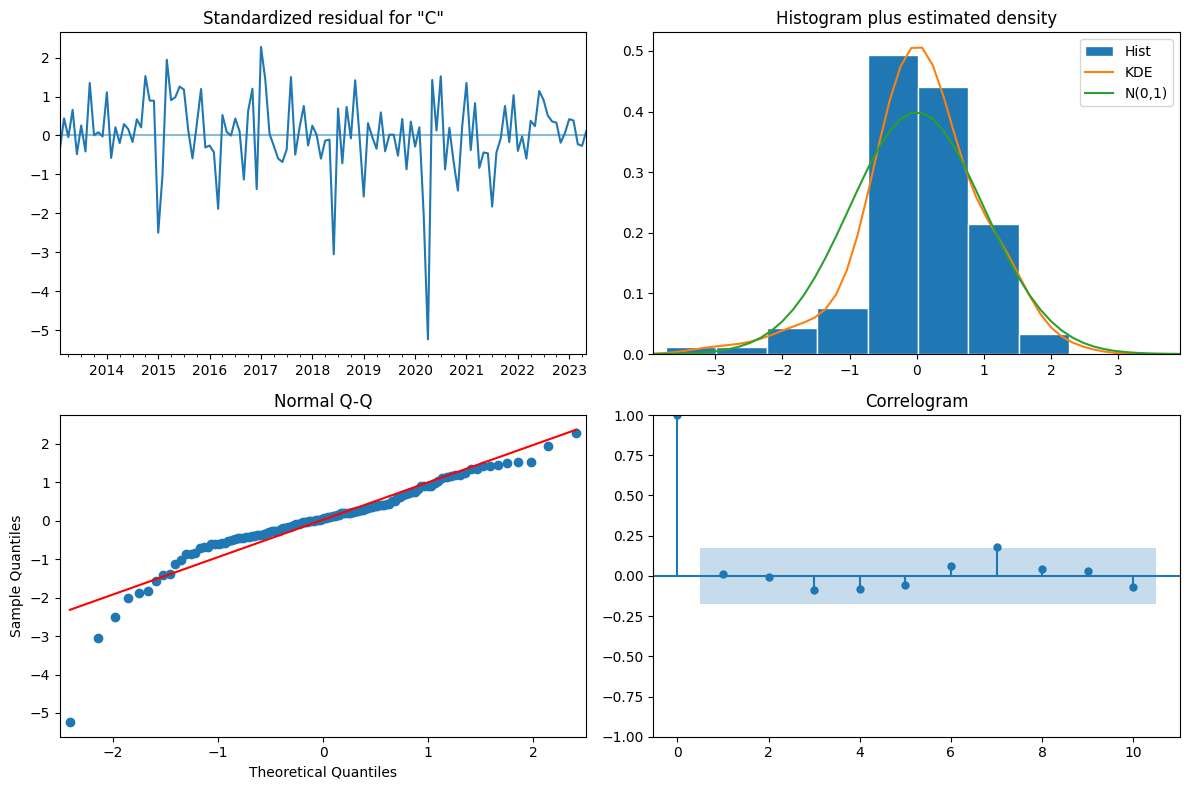

In [103]:
# Memanggil fungsi plot diagnostik terus daripada hasil model statsmodels anda
fig = best_model_arimax.plot_diagnostics(figsize=(12, 8))

# Memperkemas ruang supaya graf tidak bertindih
plt.tight_layout()
plt.show()

###**RAMALAN & UJIAN DATA UNTUK ARIMA**

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

In [92]:
# 1. Membuat ramalan
ramalan_arimax_diff = best_model_arimax.predict(start=X_uji.index[0], end=X_uji.index[-1], exog=X_uji)

In [93]:
# 2. Transformasi songsang
ramalan_arimax_index = cpi_terakhir_latihan + np.cumsum(ramalan_arimax_diff)

In [94]:
# 3. Menilai Prestasi
r2_arimax = r2_score(y_uji_asal, ramalan_arimax_index)
mae_arimax = mean_absolute_error(y_uji_asal, ramalan_arimax_index)
rmse_arimax = np.sqrt(mean_squared_error(y_uji_asal, ramalan_arimax_index))

In [95]:
print("\n" + "="*50)
print(f"PRESTASI MODEL AUTOMATED ARIMAX{best_order} PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_arimax:.4f}")
print(f"MAE            : {mae_arimax:.4f}")
print(f"RMSE           : {rmse_arimax:.4f}")
print("="*50)


PRESTASI MODEL AUTOMATED ARIMAX(0, 0, 2) PADA DATA UJIAN
R-Squared (R2) : 0.8229
MAE            : 0.5869
RMSE           : 0.6735


Model ARIMA(0,0,2) mencatatkan nilai $R^2$ yang positif tinggi ( 0.8229).

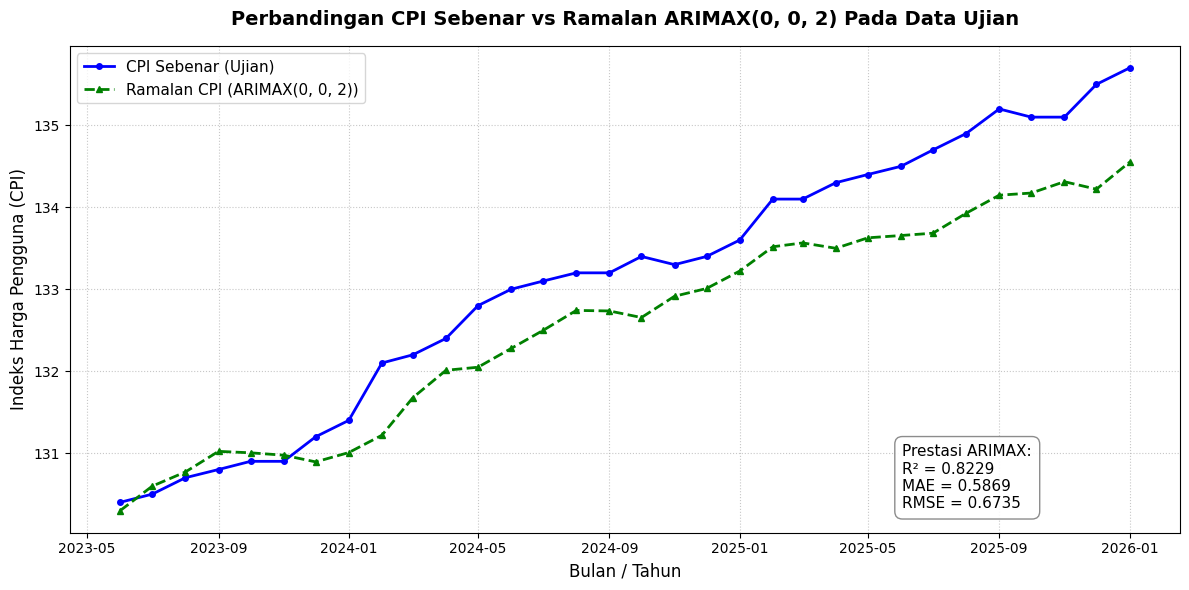

In [96]:
plt.figure(figsize=(12, 6))

# Plot Data Sebenar
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Data Ramalan ARIMAX Pilihan Bijak
plt.plot(y_uji_asal.index, ramalan_arimax_index,
         label=f'Ramalan CPI (ARIMAX{best_order})', color='green', linestyle='--', linewidth=2, marker='^', markersize=4)

# Kosmetik Graf
plt.title(f'Perbandingan CPI Sebenar vs Ramalan ARIMAX{best_order} Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Kotak Prestasi diletakkan di sebelah KANAN BAWAH supaya kemas
kotak_metrik_arimax = f'Prestasi ARIMAX:\nR² = {r2_arimax:.4f}\nMAE = {mae_arimax:.4f}\nRMSE = {rmse_arimax:.4f}'
plt.text(0.75, 0.05, kotak_metrik_arimax,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

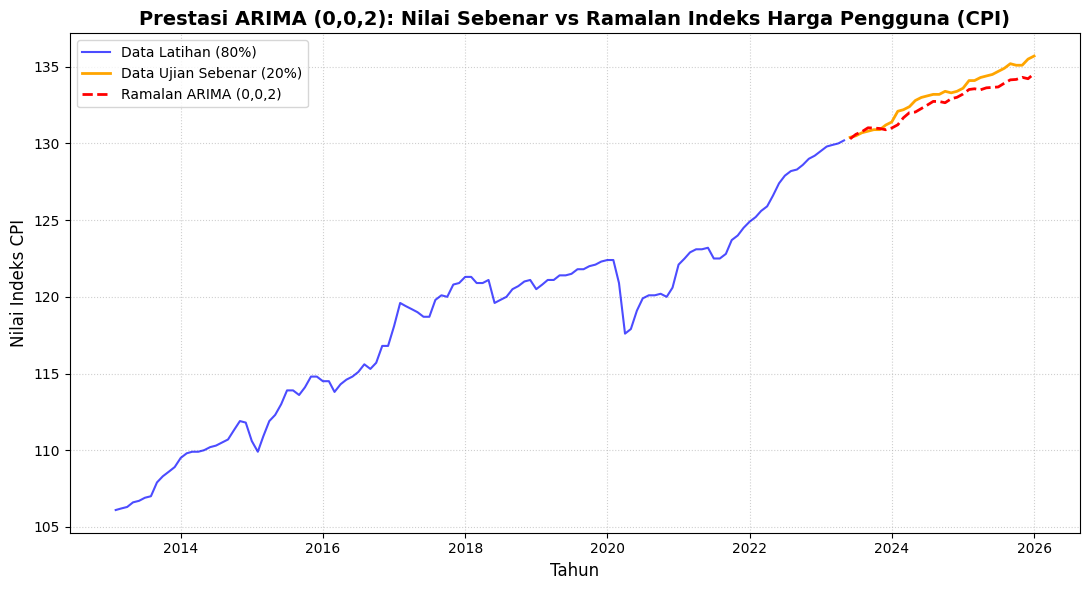

In [116]:
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_arimax_index, label=f'Ramalan ARIMA (0,0,2)', color='red', linestyle='--', linewidth=2)

plt.title(f'Prestasi ARIMA (0,0,2): Nilai Sebenar vs Ramalan Indeks Harga Pengguna (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Berdasarkan carian grid sebelum ini, kombinasi pemenang bagi siri masa ini ialah ARIMA(0, 0, 2). Oleh kerana komponen Autoregressive ialah $p=0$, model ini tidak mempunyai "ingatan" jangka panjang daripada data sejarah. Komponen Moving Average pula hanya $q=2$, bermaksud kapasiti ralatnya terpadam selepas 2 bulan sahaja.

###**ARIMA TANPA MENETAPKAN d=0**

In [104]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [105]:
# 1. Gunakan nama pembolehubah asal dari df_bersih
senarai_x_asal = ['OPR_Rate', 'PPI_Index', 'Unemployment_Rate', 'M3_Total', 'USD_Avg']

In [106]:
# 2. Potong data untuk pemboleh ubah asal
X_latih_asal = df_bersih[senarai_x_asal].iloc[:saiz_latihan]
X_uji_asal = df_bersih[senarai_x_asal].iloc[saiz_latihan:]
y_latih_asal_model = df_bersih['CPI_Index'].iloc[:saiz_latihan]

In [107]:
# 3. Grid Search
best_aic_raw = float("inf")
best_order_raw = None
best_model_raw = None

In [110]:
# 4. Cari model terbaik
for p in range(3):
    for d in range(3):
        for q in range(3):
            try:
                model_terai = SARIMAX(endog=y_latih_asal_model,
                                      exog=X_latih_asal,
                                      order=(p, d, q),
                                      trend='c')
                keputusan_terai = model_terai.fit(disp=False)

                if keputusan_terai.aic < best_aic_raw:
                    best_aic_raw = keputusan_terai.aic
                    best_order_raw = (p, d, q)
                    best_model_raw = keputusan_terai
            except:
                continue

In [111]:
print(f"\n>> Model Terbaik Dipilih (Raw): ARIMAX{best_order_raw}")
print(f">> Nilai AIC Terbaik: {best_aic_raw:.4f}\n")
print(best_model_raw.summary())


>> Model Terbaik Dipilih (Raw): ARIMAX(0, 1, 0)
>> Nilai AIC Terbaik: 174.4232

                               SARIMAX Results                                
Dep. Variable:              CPI_Index   No. Observations:                  124
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -80.212
Date:                Tue, 09 Jun 2026   AIC                            174.423
Time:                        14:50:09   BIC                            194.108
Sample:                    02-01-2013   HQIC                           182.419
                         - 05-01-2023                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.1405      0.055      2.553      0.011       0.033       0.248
OPR_Rate              0.0051 

###**RAMALAN & UJIAN DATA ARIMA TANPA d=0**

In [112]:
# 1. Membuat Ramalan
ramalan_arimax_raw = best_model_raw.predict(start=X_uji_asal.index[0],end=X_uji_asal.index[-1],exog=X_uji_asal)

In [113]:
# 2. Menilai Prestasi
r2_arimax_raw = r2_score(y_uji_asal, ramalan_arimax_raw)
mae_arimax_raw = mean_absolute_error(y_uji_asal, ramalan_arimax_raw)
rmse_arimax_raw = np.sqrt(mean_squared_error(y_uji_asal, ramalan_arimax_raw))

In [114]:
print("\n" + "="*50)
print(f"PRESTASI ARIMAX{best_order_raw} (RAW DATA) PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_arimax_raw:.4f}")
print(f"MAE            : {mae_arimax_raw:.4f}")
print(f"RMSE           : {rmse_arimax_raw:.4f}")
print("="*50)


PRESTASI ARIMAX(0, 1, 0) (RAW DATA) PADA DATA UJIAN
R-Squared (R2) : 0.7440
MAE            : 0.7115
RMSE           : 0.8097


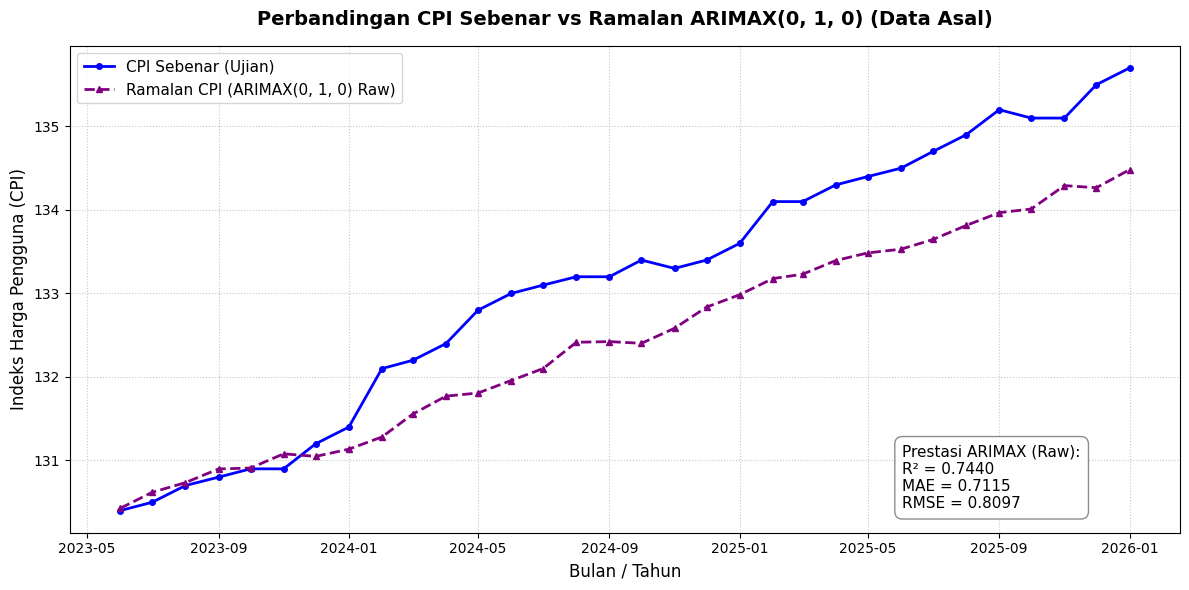

In [115]:
plt.figure(figsize=(12, 6))

# Plot Data Sebenar
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Data Ramalan ARIMAX Raw (Warna Ungu untuk bezakan dengan graf lama)
plt.plot(y_uji_asal.index, ramalan_arimax_raw,
         label=f'Ramalan CPI (ARIMAX{best_order_raw} Raw)', color='purple', linestyle='--', linewidth=2, marker='^', markersize=4)

# Kosmetik Graf
plt.title(f'Perbandingan CPI Sebenar vs Ramalan ARIMAX{best_order_raw} (Data Asal)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Kotak Prestasi diletakkan di sebelah kanan bawah menggunakan nilai _raw
kotak_metrik_raw = f'Prestasi ARIMAX (Raw):\nR² = {r2_arimax_raw:.4f}\nMAE = {mae_arimax_raw:.4f}\nRMSE = {rmse_arimax_raw:.4f}'
plt.text(0.75, 0.05, kotak_metrik_raw,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

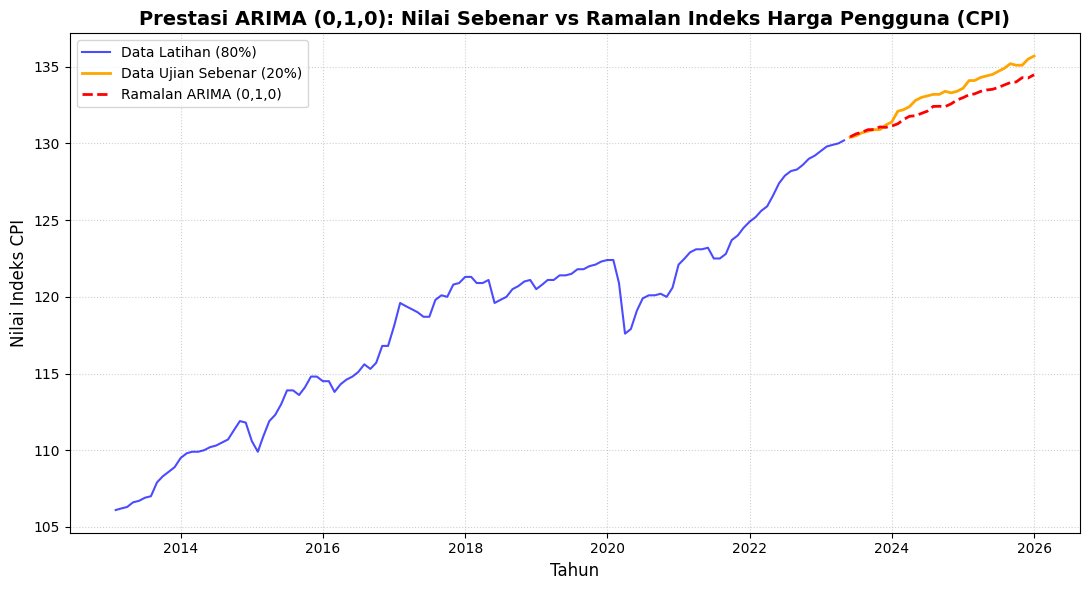

In [117]:
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_arimax_raw, label=f'Ramalan ARIMA (0,1,0)', color='red', linestyle='--', linewidth=2)

plt.title(f'Prestasi ARIMA (0,1,0): Nilai Sebenar vs Ramalan Indeks Harga Pengguna (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

ARIMA (0,0,2) adalah lebih baik berbanding ARIMA (0,1,0)

###**LASSO REGRESSION**

In [121]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [122]:
# 1. Piawaikan data
scaler_lasso = StandardScaler()
X_latih_skala = scaler_lasso.fit_transform(X_latih)
X_uji_skala = scaler_lasso.transform(X_uji)

In [123]:
# 2. Tetapkan Time Series Cross-Validation secara asing yang tidak random
tscv_lasso = TimeSeriesSplit(n_splits=5)

In [125]:
# 2. Mengolah model melaui GridSearchCV
lasso_model = Lasso(random_state=42, max_iter=10000)

In [128]:
# 3. Menguji pelbagai nilai penalti alpha
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
grid_search_lasso = GridSearchCV(estimator=lasso_model,
                                 param_grid=param_grid_lasso,
                                 cv=tscv_lasso,
                                 scoring='neg_mean_absolute_error',
                                 n_jobs=-1)

In [129]:
# 4. Latih model menggunakan data sasaran CPI_diff
grid_search_lasso.fit(X_latih_skala, y_latih_diff)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Lasso(max_iter=10000, random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]},
             scoring='neg_mean_absolute_error')

In [133]:
# 5. Ambil parameter terbaik yang dipilih oleh Python
alpha_terbaik = grid_search_lasso.best_params_['alpha']
model_lasso_terbaik = grid_search_lasso.best_estimator_
print(f"Nilai Alpha Pemenang Ditemui: {alpha_terbaik}")

Nilai Alpha Pemenang Ditemui: 0.1


###**RAMALAN & UJIAN DATA LASSO REGRESSION**

In [134]:
# 1. Membuat ramalan
ramalan_lasso_diff = model_lasso_terbaik.predict(X_uji_skala)

In [135]:
# 2. Transformasi songsang
ramalan_lasso_index = cpi_terakhir_latihan + np.cumsum(ramalan_lasso_diff)

In [136]:
# 3. Penilaian prestasi
r2_lasso = r2_score(y_uji_asal, ramalan_lasso_index)
mae_lasso = mean_absolute_error(y_uji_asal, ramalan_lasso_index)
rmse_lasso = np.sqrt(mean_squared_error(y_uji_asal, ramalan_lasso_index))

In [137]:
print("\n" + "="*50)
print("PRESTASI MODEL LASSO REGRESSION PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_lasso:.4f}")
print(f"MAE            : {mae_lasso:.4f}")
print(f"RMSE           : {rmse_lasso:.4f}")
print("="*50)


PRESTASI MODEL LASSO REGRESSION PADA DATA UJIAN
R-Squared (R2) : 0.9744
MAE            : 0.2218
RMSE           : 0.2561


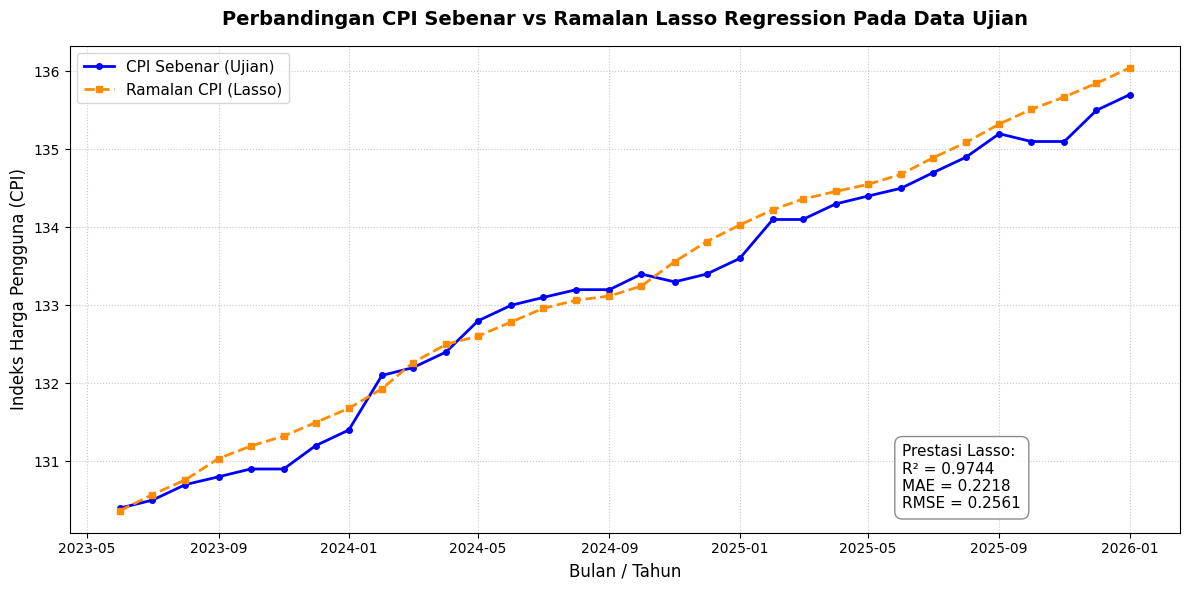

In [138]:
plt.figure(figsize=(12, 6))

# Plot Garisan CPI Sebenar (Warna Biru)
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Garisan Ramalan Lasso (Warna Jingga/Orange untuk membedakan dari OLS dan ARIMAX)
plt.plot(y_uji_asal.index, ramalan_lasso_index,
         label='Ramalan CPI (Lasso)', color='darkorange', linestyle='--', linewidth=2, marker='s', markersize=4)

# Tetapan Kosmetik Graf
plt.title('Perbandingan CPI Sebenar vs Ramalan Lasso Regression Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Meletakkan kotak prestasi di sebelah KANAN BAWAH (Koordinat 0.75, 0.05)
kotak_metrik_lasso = f'Prestasi Lasso:\nR² = {r2_lasso:.4f}\nMAE = {mae_lasso:.4f}\nRMSE = {rmse_lasso:.4f}'
plt.text(0.75, 0.05, kotak_metrik_lasso,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

In [142]:
# 1. Semakan pengeluaran ciri : Ambil nilai pekali (coefficients) dari model Lasso terbaik
pekali_lasso = model_lasso_terbaik.coef_

In [143]:
# 2. Padankan nilai pekali dengan nama pembolehubah X yang kita gunakan
df_ciri_lasso = pd.DataFrame({
    'Pembolehubah X': senarai_x_pegun,
    'Pekali (Coefficient)': pekali_lasso})

In [144]:
# 3. Ambil nilai mutlak (absolute value) untuk menyusun kekuatan (Kuat Di Atas)
df_ciri_lasso['Kekuatan Mutlak'] = df_ciri_lasso['Pekali (Coefficient)'].abs()
df_ciri_lasso_tersusun = df_ciri_lasso.sort_values(by='Kekuatan Mutlak', ascending=False).reset_index(drop=True)

In [145]:
print("\nJadual Sumbangan Pembolehubah Makroekonomi Terhadap Model Lasso:")
print("=" * 65)
print(df_ciri_lasso_tersusun[['Pembolehubah X', 'Pekali (Coefficient)']])
print("=" * 65)


Jadual Sumbangan Pembolehubah Makroekonomi Terhadap Model Lasso:
      Pembolehubah X  Pekali (Coefficient)
0     PPI_Index_diff              0.090221
1      OPR_Rate_diff              0.000000
2  Unemployment_Rate             -0.000000
3      M3_Total_diff             -0.000000
4       USD_Avg_diff             -0.000000


In [147]:
# 4. Ciri yang digugurkan
lajur_digugurkan = df_ciri_lasso_tersusun[df_ciri_lasso_tersusun['Pekali (Coefficient)'] == 0]
if len(lajur_digugurkan) > 0:
    print("\nModel Lasso telah menggugurkan ciri berikut (Pekali = 0):")
    for var in lajur_digugurkan['Pembolehubah X']:
        print(f" - {var}")
else:
    print("\nSemua pembolehubah X memberi sumbangan (Tiada ciri yang digugurkan).")


Model Lasso telah menggugurkan ciri berikut (Pekali = 0):
 - OPR_Rate_diff
 - Unemployment_Rate
 - M3_Total_diff
 - USD_Avg_diff


###**RANDOM FOREST**

In [148]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [149]:
# 1. Panggil balik untuk memori
senarai_x_pegun = ['OPR_Rate_diff', 'PPI_Index_diff', 'Unemployment_Rate', 'M3_Total_diff', 'USD_Avg_diff']

In [150]:
# 2. Tetapkan Time Series Cross-Validation khas untuk Random Forest
tscv_rf = TimeSeriesSplit(n_splits=5)

In [151]:
# 2.  Menapis data untuk Recursive Feature Elimination (RFE)
rf_asas_selector = RandomForestRegressor(random_state=42)

In [152]:
# 3. Menggunakan RFECV untuk membuang ciri yang tidak relevan secara saintifik
rfecv = RFECV(estimator=rf_asas_selector,step=1,cv=tscv_rf,scoring='neg_mean_absolute_error',n_jobs=-1)
rfecv.fit(X_latih, y_latih_diff)

RFECV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
      estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
      scoring='neg_mean_absolute_error')

In [153]:
# 4. Mengekstrak pembolehubah makroekonomi yang melepasi tapisan RFE
fitur_terpilih_rf = list(np.array(senarai_x_pegun)[rfecv.support_])
print(f">> Bilangan Ciri Optimum Dipilih: {rfecv.n_features_} daripada 5")
print(f">> Pembolehubah Yang Kekal: {fitur_terpilih_rf}")

>> Bilangan Ciri Optimum Dipilih: 2 daripada 5
>> Pembolehubah Yang Kekal: [np.str_('PPI_Index_diff'), np.str_('Unemployment_Rate')]


In [154]:
# 5. Memperkemas X dengan HANYA menggunakan ciri-ciri yang telah lulus tapisan RFE
X_latih_rfe = X_latih[fitur_terpilih_rf]
X_uji_rfe = X_uji[fitur_terpilih_rf]

In [155]:
# 6. Mencari model RF terbaik
rf_model = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]}

grid_search_rf = GridSearchCV(estimator=rf_model,param_grid=param_grid_rf, cv=tscv_rf, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search_rf.fit(X_latih_rfe, y_latih_diff)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [156]:
# 7. Model terbaik
model_rf_terbaik = grid_search_rf.best_estimator_
print(f"Kombinasi Parameter Pemenang: {grid_search_rf.best_params_}")

Kombinasi Parameter Pemenang: {'max_depth': 5, 'n_estimators': 200}


###**RAMALAN & UJIAN DATA RANDOM FOREST**

In [157]:
# 1. Membuat Ramalan
ramalan_rf_diff = model_rf_terbaik.predict(X_uji_rfe)

In [158]:
# 2. Transformasi Songsang
ramalan_rf_index = cpi_terakhir_latihan + np.cumsum(ramalan_rf_diff)

In [159]:
# 3. Menilai prestasi
r2_rf = r2_score(y_uji_asal, ramalan_rf_index)
mae_rf = mean_absolute_error(y_uji_asal, ramalan_rf_index)
rmse_rf = np.sqrt(mean_squared_error(y_uji_asal, ramalan_rf_index))

In [160]:
print("\n" + "="*50)
print("PRESTASI MODEL RANDOM FOREST + RFE PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_rf:.4f}")
print(f"MAE            : {mae_rf:.4f}")
print(f"RMSE           : {rmse_rf:.4f}")
print("="*50)


PRESTASI MODEL RANDOM FOREST + RFE PADA DATA UJIAN
R-Squared (R2) : 0.7087
MAE            : 0.6078
RMSE           : 0.8638


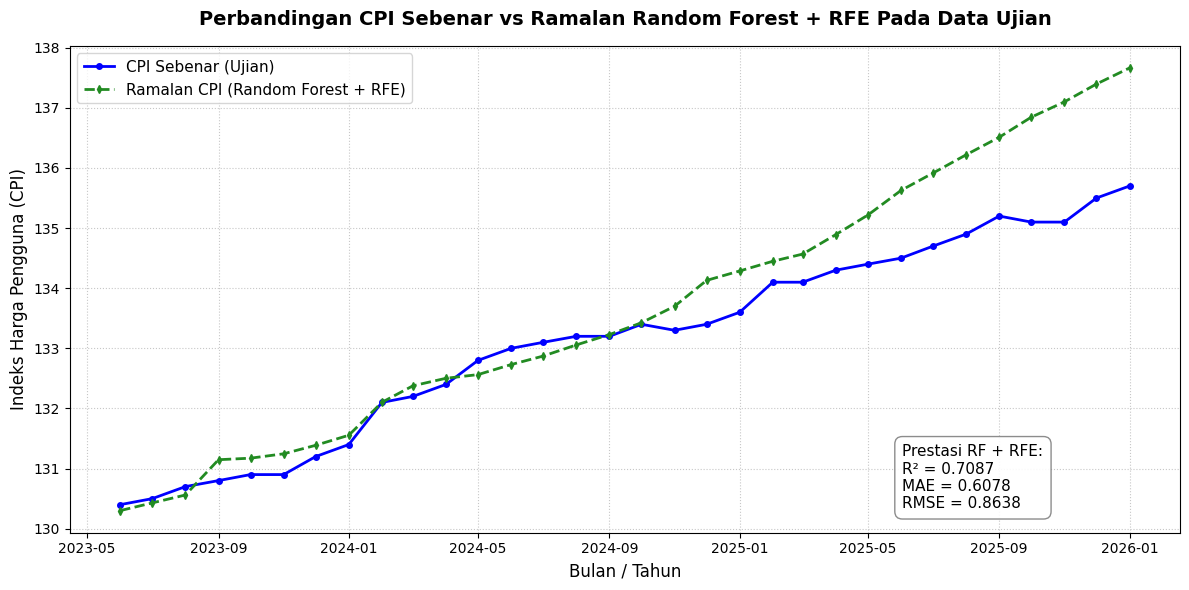

In [161]:
plt.figure(figsize=(12, 6))

# Plot Garisan CPI Sebenar (Warna Biru)
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Garisan Ramalan Random Forest (Warna Hijau Forest)
plt.plot(y_uji_asal.index, ramalan_rf_index,
         label='Ramalan CPI (Random Forest + RFE)', color='forestgreen', linestyle='--', linewidth=2, marker='d', markersize=4)

# Tetapan Kosmetik Graf
plt.title('Perbandingan CPI Sebenar vs Ramalan Random Forest + RFE Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Meletakkan kotak prestasi di sebelah KANAN BAWAH (Koordinat 0.75, 0.05)
kotak_metrik_rf = f'Prestasi RF + RFE:\nR² = {r2_rf:.4f}\nMAE = {mae_rf:.4f}\nRMSE = {rmse_rf:.4f}'
plt.text(0.75, 0.05, kotak_metrik_rf,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

###**RANDOM FOREST TANPA RFE**

In [162]:
# 1. Tetapkan Time Series Cross-Validation
tscv_tanpa_rfe = TimeSeriesSplit(n_splits=5)

In [163]:
# 2. Mencari model melalui GridSearchCV
rf_asas_tanpa_rfe = RandomForestRegressor(random_state=42)

# Menguji pelbagai kombinasi saiz pokok dan kedalaman
param_grid_tanpa_rfe = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]}

grid_search_tanpa_rfe = GridSearchCV(estimator=rf_asas_tanpa_rfe,
                                     param_grid=param_grid_tanpa_rfe,
                                     cv=tscv_tanpa_rfe,
                                     scoring='neg_mean_absolute_error',
                                     n_jobs=-1)

In [165]:
# 3. Latih model
grid_search_tanpa_rfe.fit(X_latih, y_latih_diff)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [166]:
# 4. Model terbaik
model_rf_tanpa_rfe = grid_search_tanpa_rfe.best_estimator_
print(f"Kombinasi Parameter Pemenang Ditemui: {grid_search_tanpa_rfe.best_params_}")

Kombinasi Parameter Pemenang Ditemui: {'max_depth': 5, 'n_estimators': 200}


###**RAMALAN & UJIAN DATA RANDOM FOREST TANPA RFE**

In [167]:
# 1. Ramalan
ramalan_diff_tanpa_rfe = model_rf_tanpa_rfe.predict(X_uji)

In [168]:
# 2. Transformasi Songsang
ramalan_index_tanpa_rfe = cpi_terakhir_latihan + np.cumsum(ramalan_diff_tanpa_rfe)

In [169]:
# 3. Penilaian prestasi
r2_tanpa_rfe = r2_score(y_uji_asal, ramalan_index_tanpa_rfe)
mae_tanpa_rfe = mean_absolute_error(y_uji_asal, ramalan_index_tanpa_rfe)
rmse_tanpa_rfe = np.sqrt(mean_squared_error(y_uji_asal, ramalan_index_tanpa_rfe))

In [170]:
print("\n" + "="*50)
print("PRESTASI MODEL RANDOM FOREST (TANPA RFE) PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_tanpa_rfe:.4f}")
print(f"MAE            : {mae_tanpa_rfe:.4f}")
print(f"RMSE           : {rmse_tanpa_rfe:.4f}")
print("="*50)


PRESTASI MODEL RANDOM FOREST (TANPA RFE) PADA DATA UJIAN
R-Squared (R2) : 0.9332
MAE            : 0.3328
RMSE           : 0.4138


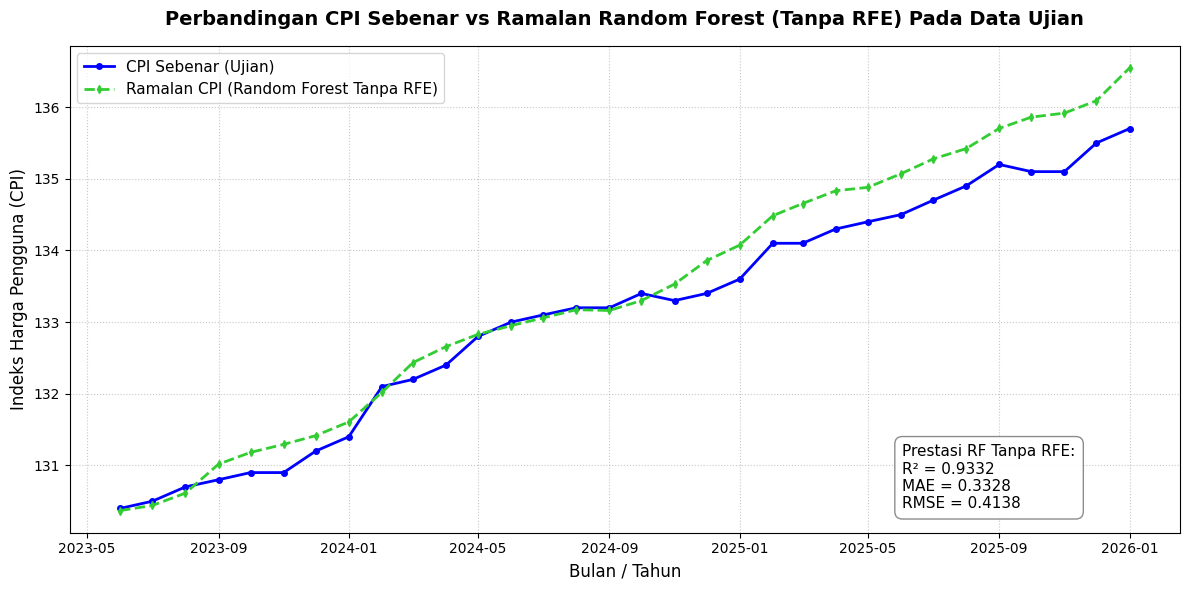

In [171]:
plt.figure(figsize=(12, 6))

# Plot Garisan CPI Sebenar (Warna Biru)
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Garisan Ramalan Random Forest Penuh (Warna Lime Green)
plt.plot(y_uji_asal.index, ramalan_index_tanpa_rfe,
         label='Ramalan CPI (Random Forest Tanpa RFE)', color='limegreen', linestyle='--', linewidth=2, marker='d', markersize=4)

# Tetapan Kosmetik Graf
plt.title('Perbandingan CPI Sebenar vs Ramalan Random Forest (Tanpa RFE) Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Kotak Prestasi diletakkan di sebelah KANAN BAWAH menggunakan nama pembolehubah baharu
kotak_metrik_tanpa_rfe = f'Prestasi RF Tanpa RFE:\nR² = {r2_tanpa_rfe:.4f}\nMAE = {mae_tanpa_rfe:.4f}\nRMSE = {rmse_tanpa_rfe:.4f}'
plt.text(0.75, 0.05, kotak_metrik_tanpa_rfe,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

Random forest tanpa RFE lebih baik berbanding Random Forest dengan RFE

###**XGBOOST**

In [174]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [175]:
# 1. Panggil semula
senarai_x_pegun = ['OPR_Rate_diff', 'PPI_Index_diff', 'Unemployment_Rate', 'M3_Total_diff', 'USD_Avg_diff']

In [181]:
# 2. Tetapkan Time Series Cross-Validation unik untuk XGBoost
tscv_xgb_rfe = TimeSeriesSplit(n_splits=5)

In [182]:
# 2. Menapis data Recursive Feature Elimination (RFE)
xgb_asas_selector = XGBRegressor(objective='reg:squarederror', random_state=42)

In [184]:
# 3. Menggunakan RFECV untuk membuang ciri yang tidak releven
rfecv_xgb = RFECV(estimator=xgb_asas_selector,step=1, cv=tscv_xgb_rfe, scoring='neg_mean_absolute_error', n_jobs=-1)
rfecv_xgb.fit(X_latih, y_latih_diff)

RFECV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
      estimator=XGBRegressor(base_score=None, booster=None, callbacks=None,
                             colsample_bylevel=None, colsample_bynode=None,
                             colsample_bytree=None, device=None,
                             early_stopping_rounds=None,
                             enable_categorical=False, eval_metric=None,
                             feature_types=None, feature_weights=None,
                             gamma=None, grow_p...type=None,
                             interaction_constraints=None, learning_rate=None,
                             max_bin=None, max_cat_threshold=None,
                             max_cat_to_onehot=None, max_delta_step=None,
                             max_depth=None, max_leaves=None,
                             min_child_weight=None, missing=nan,
                             monotone_constraints=None, multi_strategy=None,
                             n_estimators=None, n_jobs=None,
                             num_parallel_tree=None, ...),
      n_jobs=-1, scoring='neg_mean_absolute_error')

In [185]:
# 4. Ekstrak ciri yang terpilih oleh XGBoost
fitur_terpilih_xgb = list(np.array(senarai_x_pegun)[rfecv_xgb.support_])
print(f">> Bilangan Ciri Optimum Dipilih: {rfecv_xgb.n_features_} daripada 5")
print(f">> Pembolehubah Yang Kekal: {fitur_terpilih_xgb}")

>> Bilangan Ciri Optimum Dipilih: 2 daripada 5
>> Pembolehubah Yang Kekal: [np.str_('OPR_Rate_diff'), np.str_('Unemployment_Rate')]


In [186]:
# 5. Tapis data X_latih dan X_uji mengikut pilihan RFE XGBoost
X_latih_xgb_rfe = X_latih[fitur_terpilih_xgb]
X_uji_xgb_rfe = X_uji[fitur_terpilih_xgb]

In [187]:
# 6. Mencari model terbaik
xgb_model_rfe = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid_xgb_rfe = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]}

grid_search_xgb_rfe = GridSearchCV(estimator=xgb_model_rfe,
                                   param_grid=param_grid_xgb_rfe,
                                   cv=tscv_xgb_rfe,
                                   scoring='neg_mean_absolute_error',
                                   n_jobs=-1)
grid_search_xgb_rfe.fit(X_latih_xgb_rfe, y_latih_diff)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [190]:
# 7. Ambil model terbaik
model_xgb_rfe_terbaik = grid_search_xgb_rfe.best_estimator_
print(f"Kombinasi Parameter Pemenang: {grid_search_xgb_rfe.best_params_}")

Kombinasi Parameter Pemenang: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


###**RAMALAN & UJIAN DATA XGBOOST**

In [191]:
# 1. Membuat ramalan
ramalan_diff_xgb_rfe = model_xgb_rfe_terbaik.predict(X_uji_xgb_rfe)

In [192]:
# 2. Transformasi songsang
ramalan_index_xgb_rfe = cpi_terakhir_latihan + np.cumsum(ramalan_diff_xgb_rfe)

In [193]:
# 2. Penilaian prestasi
r2_xgb_rfe = r2_score(y_uji_asal, ramalan_index_xgb_rfe)
mae_xgb_rfe = mean_absolute_error(y_uji_asal, ramalan_index_xgb_rfe)
rmse_xgb_rfe = np.sqrt(mean_squared_error(y_uji_asal, ramalan_index_xgb_rfe))

In [194]:
print("\n" + "="*50)
print("PRESTASI MODEL XGBOOST + RFE PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_xgb_rfe:.4f}")
print(f"MAE            : {mae_xgb_rfe:.4f}")
print(f"RMSE           : {rmse_xgb_rfe:.4f}")
print("="*50)


PRESTASI MODEL XGBOOST + RFE PADA DATA UJIAN
R-Squared (R2) : 0.8945
MAE            : 0.4134
RMSE           : 0.5198


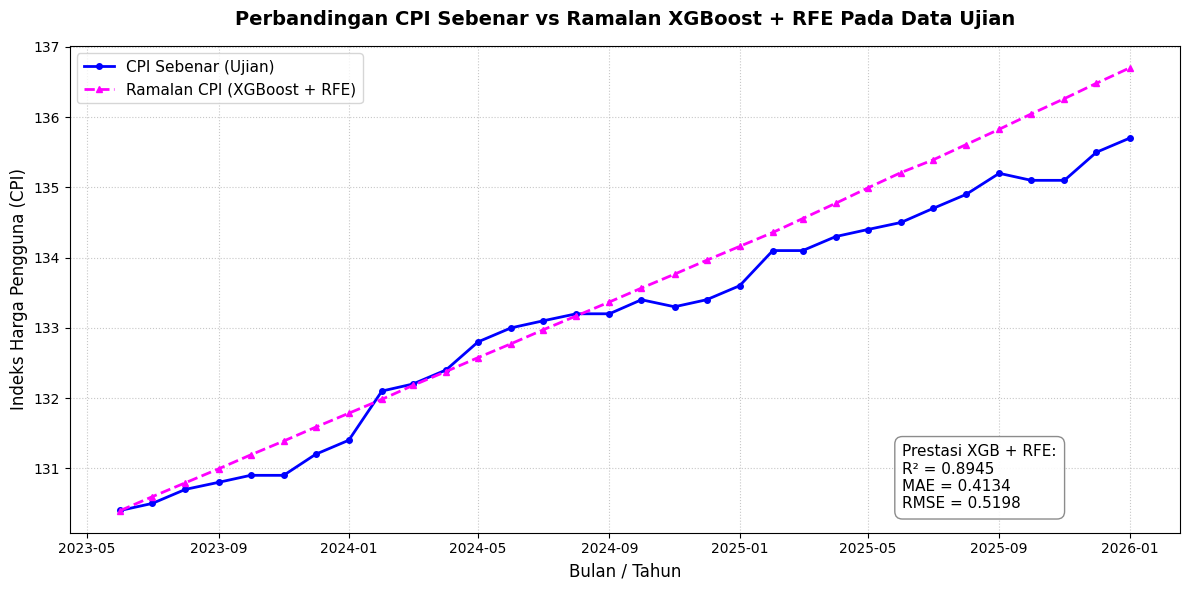

In [195]:
# 4. Plot graf perbandingan
plt.figure(figsize=(12, 6))

# Plot Garisan CPI Sebenar (Warna Biru)
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Garisan Ramalan XGBoost + RFE (Warna Fuchsia)
plt.plot(y_uji_asal.index, ramalan_index_xgb_rfe,
         label='Ramalan CPI (XGBoost + RFE)', color='fuchsia', linestyle='--', linewidth=2, marker='^', markersize=4)

# Tetapan Kosmetik Graf
plt.title('Perbandingan CPI Sebenar vs Ramalan XGBoost + RFE Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Meletakkan kotak prestasi di sebelah KANAN BAWAH (Koordinat 0.75, 0.05)
kotak_metrik_xgb_rfe = f'Prestasi XGB + RFE:\nR² = {r2_xgb_rfe:.4f}\nMAE = {mae_xgb_rfe:.4f}\nRMSE = {rmse_xgb_rfe:.4f}'
plt.text(0.75, 0.05, kotak_metrik_xgb_rfe,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

###**XGBOOST TANPA RFE**

In [196]:
# 1. Tetapkan Time Series Cross-Validation
tscv_xgb_tanpa_rfe = TimeSeriesSplit(n_splits=5)

In [197]:
# 2. Sediakan Model Asas XGBoost
xgb_asas_tanpa_rfe = XGBRegressor(objective='reg:squarederror', random_state=42)

In [198]:
# 3. Memperkemaskan model melalui gridsearchcv
param_grid_xgb_tanpa_rfe = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]}

In [199]:
# 4. Jalankan Grid Search menggunakan kesemua pembolehubah di dalam X_latih
grid_search_xgb_tanpa_rfe = GridSearchCV(estimator=xgb_asas_tanpa_rfe,
                                         param_grid=param_grid_xgb_tanpa_rfe,
                                         cv=tscv_xgb_tanpa_rfe,
                                         scoring='neg_mean_absolute_error',
                                         n_jobs=-1)
grid_search_xgb_tanpa_rfe.fit(X_latih, y_latih_diff)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [200]:
# 5. Ambil model terbaik
model_xgb_tanpa_rfe = grid_search_xgb_tanpa_rfe.best_estimator_
print(f"Kombinasi Parameter Pemenang: {grid_search_xgb_tanpa_rfe.best_params_}")

Kombinasi Parameter Pemenang: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


###**RAMALAN & UJIAN DATA XGBOOST TANPA RFE**

In [201]:
# 1. Buat ramalan
ramalan_diff_xgb_tanpa_rfe = model_xgb_tanpa_rfe.predict(X_uji)

In [202]:
# 2. Transformasi songsang
ramalan_index_xgb_tanpa_rfe = cpi_terakhir_latihan + np.cumsum(ramalan_diff_xgb_tanpa_rfe)

In [204]:
# 3. Penilaian prestasi
r2_xgb_tanpa_rfe = r2_score(y_uji_asal, ramalan_index_xgb_tanpa_rfe)
mae_xgb_tanpa_rfe = mean_absolute_error(y_uji_asal, ramalan_index_xgb_tanpa_rfe)
rmse_xgb_tanpa_rfe = np.sqrt(mean_squared_error(y_uji_asal, ramalan_index_xgb_tanpa_rfe))

In [205]:
print("\n" + "="*50)
print("PRESTASI MODEL XGBOOST (TANPA RFE) PADA DATA UJIAN")
print("="*50)
print(f"R-Squared (R2) : {r2_xgb_tanpa_rfe:.4f}")
print(f"MAE            : {mae_xgb_tanpa_rfe:.4f}")
print(f"RMSE           : {rmse_xgb_tanpa_rfe:.4f}")
print("="*50)


PRESTASI MODEL XGBOOST (TANPA RFE) PADA DATA UJIAN
R-Squared (R2) : 0.9288
MAE            : 0.3472
RMSE           : 0.4269


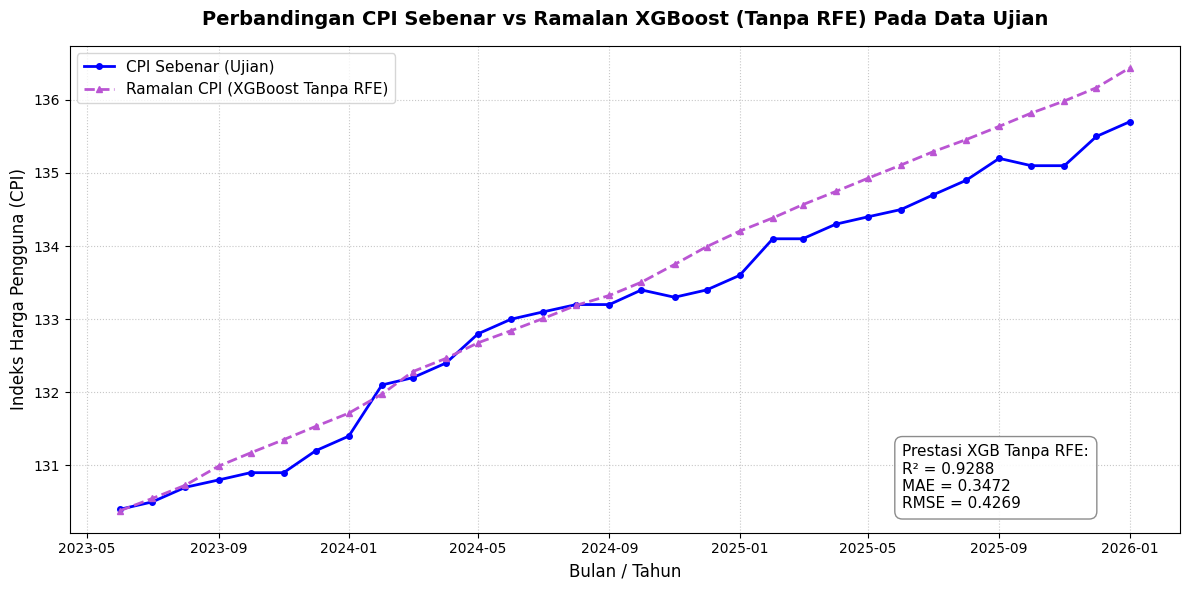

In [206]:
plt.figure(figsize=(12, 6))

# Plot Garisan CPI Sebenar (Warna Biru)
plt.plot(y_uji_asal.index, y_uji_asal.values,
         label='CPI Sebenar (Ujian)', color='blue', linewidth=2, marker='o', markersize=4)

# Plot Garisan Ramalan XGBoost Penuh (Warna Medium Orchid)
plt.plot(y_uji_asal.index, ramalan_index_xgb_tanpa_rfe,
         label='Ramalan CPI (XGBoost Tanpa RFE)', color='mediumorchid', linestyle='--', linewidth=2, marker='^', markersize=4)

# Tetapan Kosmetik Graf
plt.title('Perbandingan CPI Sebenar vs Ramalan XGBoost (Tanpa RFE) Pada Data Ujian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan / Tahun', fontsize=12)
plt.ylabel('Indeks Harga Pengguna (CPI)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Kotak Prestasi diletakkan di sebelah KANAN BAWAH menggunakan nama pembolehubah baharu
kotak_metrik_xgb_tanpa_rfe = f'Prestasi XGB Tanpa RFE:\nR² = {r2_xgb_tanpa_rfe:.4f}\nMAE = {mae_xgb_tanpa_rfe:.4f}\nRMSE = {rmse_xgb_tanpa_rfe:.4f}'
plt.text(0.75, 0.05, kotak_metrik_xgb_tanpa_rfe,
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

1. Keunggulan Model Lasso Regression
Model Lasso Regression muncul sebagai model

*   Model Lasso Regression muncul sebagai model terbaik dengan nilai $R^2$ tertinggi ($97.44\%$) serta ralat terkecil ($\text{MAE} = 0.2218$; $\text{RMSE} = 0.2561$).
*   Hubungan antara indeks harga pengguna (CPI) dengan pembolehubah makroekonomi (seperti PPI, OPR, dan kadar pengangguran) dalam jangka masa pendek didominasi oleh trend linear yang kuat. Sifat penalti L1 (L1 Regularization) pada Lasso berjaya mengecilkan pekali pembolehubah yang bertindak sebagai noise, sekali gus mengelakkan isu overfitting yang sering berlaku pada data siri masa yang kecil.

2. Paradoks Penapisan Ciri RFE (Dengan RFE vs Tanpa RFE)


*   bagi kedua-dua algoritma Machine Learning yang kompleks (Random Forest dan XGBoost), variasi Tanpa RFE memberikan keputusan yang jauh lebih tepat berbanding menggunakan penapisan RFE.
*   Model berasaskan pokok (tree-based models) seperti Random Forest dan XGBoost secara semula jadi memerlukan interaksi gabungan (multivariate splits) antara kesemua pembolehubah makroekonomi untuk memetakan corak inflasi. Apabila RFE membuang beberapa pembolehubah secara paksa, model kehilangan maklumat konteks struktur ekonomi yang penting, menyebabkan ralat $\text{RMSE}$ Random Forest melonjak daripada $0.4138$ kepada $0.8638$.


3. Keberkesanan Pra-pemprosesan Data Pegun (ARIMAX Pegun vs Raw)


*   Model Automated ARIMAX(0,0,2) yang menggunakan data yang siap diselaraskan kepegunannya memberikan ralat $\text{RMSE}$ yang lebih rendah ($0.6735$) berbanding ARIMAX(0,1,0) yang menggunakan data asal ($0.8097$).
*   Perbezaan ini membuktikan secara empirikal teori ekonometrik bahawa melakukan pembezaan (differencing) secara manual mengikut ujian kepegunan (ADF/PP test) di Fasa 1 adalah jauh lebih berkesan berbanding menyerahkan tugas pembezaan secara buta kepada model siri masa. Penambahan komponen Moving Average ($q=2$) juga membuktikan model berjaya menangkap kejutan rawak ekonomi (economic shocks) dengan lebih baik.

4. OLS Sebagai Penanda Aras (Baseline)


*   Model OLS tradisional mengekalkan kedudukan standard sebagai model asas dengan nilai $\text{RMSE} = 0.8609$. Walaupun ia tidak sepadu Lasso atau Random Forest, ia berjaya menerangkan $71.06\%$ variasi data ujian, membuktikan bahawa pemilihan 5 pembolehubah makroekonomi awal anda dari Fasa 1 adalah sangat relevan dari sudut teori ekonomi fundamental.



###**SHAP ANALYSIS**


JADUAL RUMUSAN PRESTASI PERAMALAN CPI MALAYSIA:
                    Model R-Squared (R2)    MAE   RMSE
         Lasso Regression         0.9744 0.2218 0.2561
Random Forest (Tanpa RFE)         0.9332 0.3328 0.4138
      XGBoost (Tanpa RFE)         0.9288 0.3472 0.4269
            XGBoost + RFE         0.8945 0.4134 0.5198
             ARIMAX (d=0)         0.8229 0.5869 0.6735
        ARIMAX (Raw Data)         0.7440 0.7115 0.8097
           OLS (Baseline)         0.7106 0.6677 0.8609
      Random Forest + RFE         0.7087 0.6078 0.8638

>> MODEL TERBAIK (CHAMPION): Lasso Regression <<


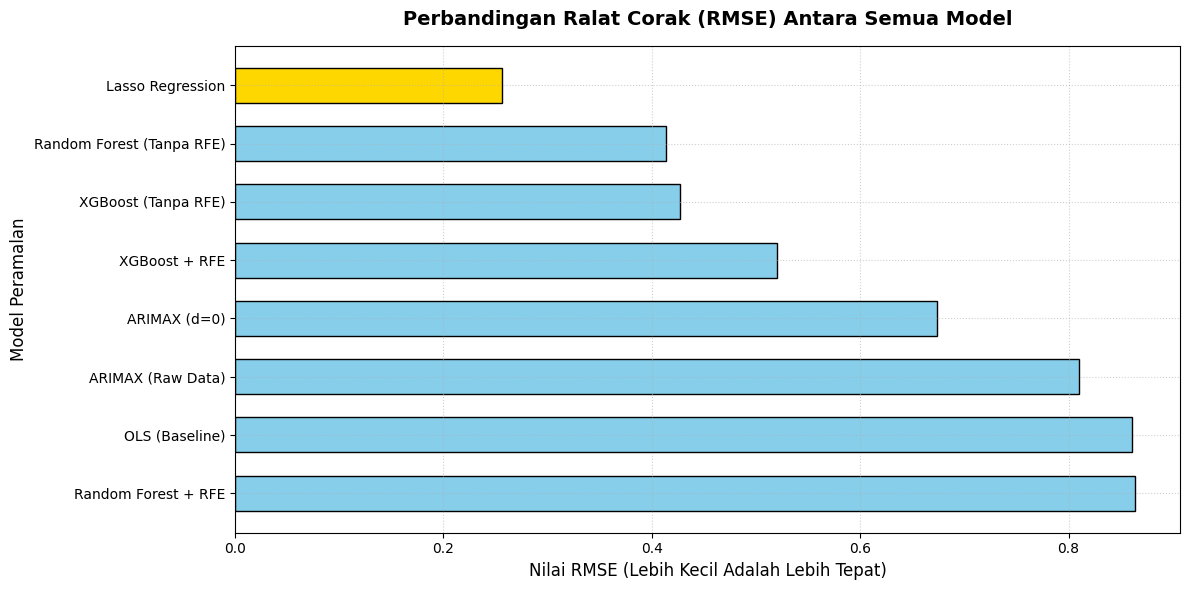

In [207]:
# 1. Himpunkan kesemua metrik prestasi yang telah disimpan dalam memori
data_rumusan = {
    'Model': [
        'OLS (Baseline)',
        'ARIMAX (d=0)',
        'ARIMAX (Raw Data)',
        'Lasso Regression',
        'Random Forest + RFE',
        'Random Forest (Tanpa RFE)',
        'XGBoost + RFE',
        'XGBoost (Tanpa RFE)'
    ],
    'R-Squared (R2)': [r2_ols, r2_arimax, r2_arimax_raw, r2_lasso, r2_rf, r2_tanpa_rfe, r2_xgb_rfe, r2_xgb_tanpa_rfe],
    'MAE': [mae_ols, mae_arimax, mae_arimax_raw, mae_lasso, mae_rf, mae_tanpa_rfe, mae_xgb_rfe, mae_xgb_tanpa_rfe],
    'RMSE': [rmse_ols, rmse_arimax, rmse_arimax_raw, rmse_lasso, rmse_rf, rmse_tanpa_rfe, rmse_xgb_rfe, rmse_xgb_tanpa_rfe]
}

# 2. Bina DataFrame dan susun mengikut RMSE secara menaik (Ralat paling kecil di ATAS)
df_master_rumusan = pd.DataFrame(data_rumusan)
df_master_rumusan_tersusun = df_master_rumusan.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

print("\nJADUAL RUMUSAN PRESTASI PERAMALAN CPI MALAYSIA:")
print("=" * 75)
print(df_master_rumusan_tersusun.to_string(index=False, formatters={
    'R-Squared (R2)': '{:,.4f}'.format, 'MAE': '{:,.4f}'.format, 'RMSE': '{:,.4f}'.format
}))
print("=" * 75)
print(f"\n>> MODEL TERBAIK: {df_master_rumusan_tersusun.iloc[0]['Model']} <<")

# 3. Graf Bar Perbandingan RMSE (Berasingan dalam sel yang sama)
plt.figure(figsize=(12, 6))
df_graf_skor = df_master_rumusan.sort_values(by='RMSE', ascending=False) # Terbalikkan untuk bar melintang

plt.barh(df_graf_skor['Model'], df_graf_skor['RMSE'],
         color=['gold' if x == df_master_rumusan_tersusun.iloc[0]['Model'] else 'skyblue' for x in df_graf_skor['Model']],
         edgecolor='black', height=0.6)

plt.title('Perbandingan Ralat Corak (RMSE) Antara Semua Model', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai RMSE (Lebih Kecil Adalah Lebih Tepat)', fontsize=12)
plt.ylabel('Model Peramalan', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

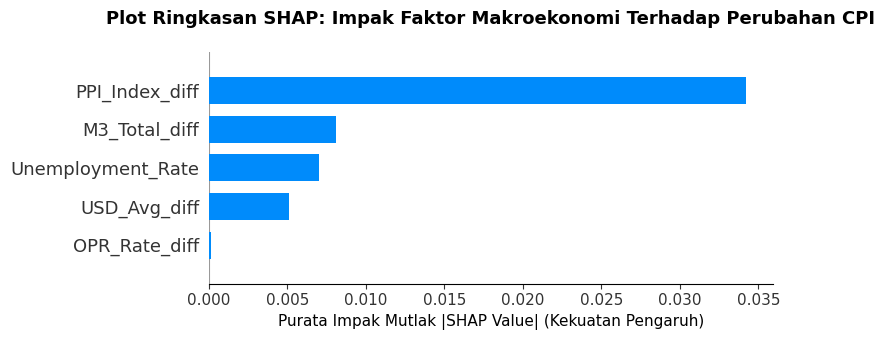

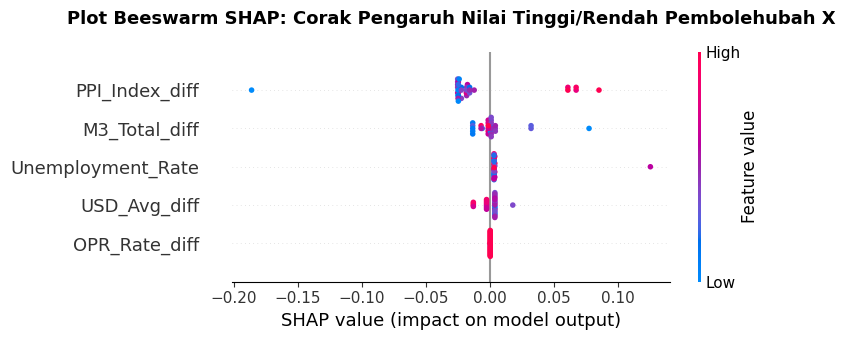

In [208]:
import shap

# 1. Bina SHAP TreeExplainer khusus untuk model berasaskan pokok (XGBoost)
explainer = shap.TreeExplainer(model_xgb_tanpa_rfe)

# 2. Kira nilai SHAP (SHAP values) untuk data ujian anda
shap_values = explainer(X_uji)

# 3. JANA PLOT RINGKASAN SHAP (SHAP Summary Plot)
# Plot ini menggabungkan kepentingan ciri dengan arah pengaruhnya
plt.figure(figsize=(10, 6))
plt.title('Plot Ringkasan SHAP: Impak Faktor Makroekonomi Terhadap Perubahan CPI', fontsize=13, fontweight='bold', pad=20)

shap.summary_plot(shap_values, X_uji, plot_type="bar", show=False)

plt.xlabel('Purata Impak Mutlak |SHAP Value| (Kekuatan Pengaruh)', fontsize=11)
plt.tight_layout()
plt.show()

# 4. JANA PLOT BEBENTUK LEBAH (SHAP Beeswarm Plot)
# Ini menunjukkan sama ada nilai pembolehubah yang TINGGI meningkatkan atau menurunkan CPI
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_uji, show=False)
plt.title('Plot Beeswarm SHAP: Corak Pengaruh Nilai Tinggi/Rendah Pembolehubah X', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

=== FASA 5.2: PENGIRAAN ANALISIS SHAP GABUNGAN ===
 - Mengekstrak nilai SHAP untuk Lasso Regression...
 - Mengekstrak nilai SHAP untuk Random Forest...
 - Mengekstrak nilai SHAP untuk XGBoost...
>> Ekstraksi berjaya! Menjana graf perbandingan...


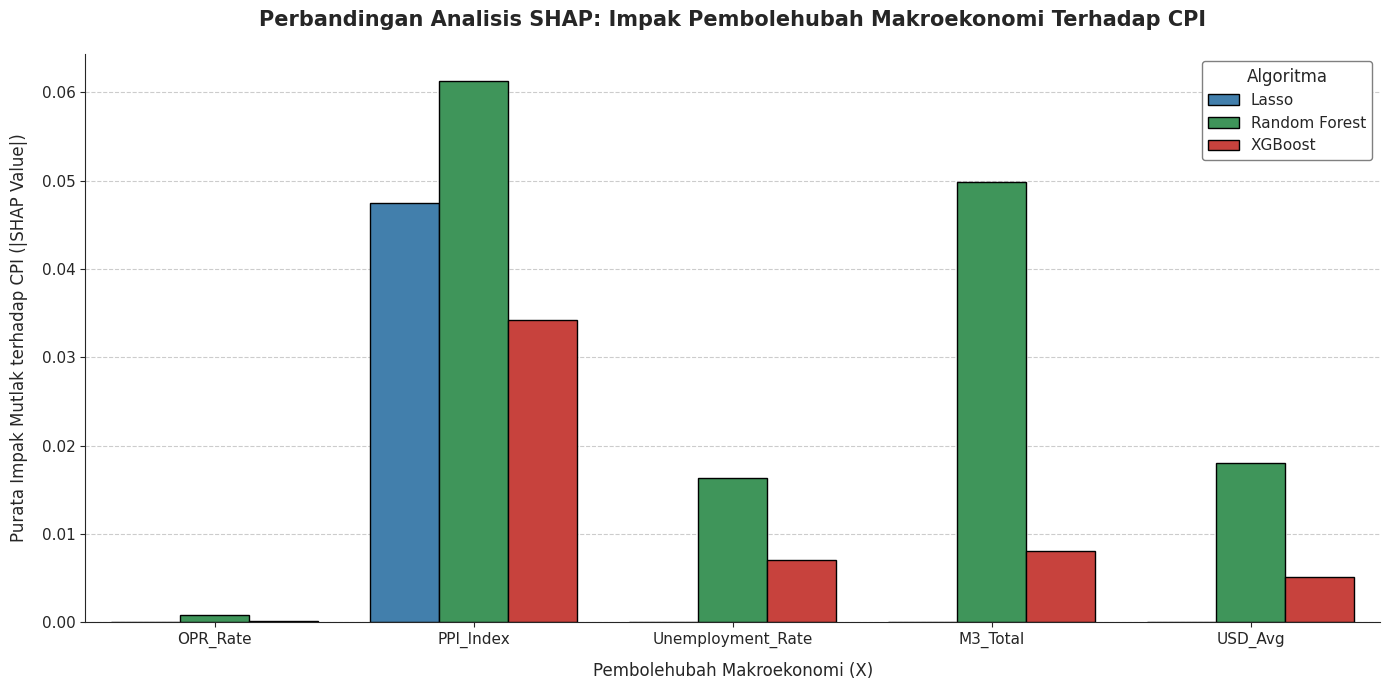

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("=== FASA 5.2: PENGIRAAN ANALISIS SHAP GABUNGAN ===")

# Dictionary untuk menukar nama lajur pegun (_diff) kepada nama asal yang bersih untuk paparan graf
pemetaan_nama = {
    'OPR_Rate_diff': 'OPR_Rate',
    'PPI_Index_diff': 'PPI_Index',
    'Unemployment_Rate': 'Unemployment_Rate',
    'M3_Total_diff': 'M3_Total',
    'USD_Avg_diff': 'USD_Avg'
}

# 1. Fungsi pengiraan SHAP untuk Tree-Based Models (RF & XGBoost)
def kira_shap_tree(model, X_data, nama_model, pemetaan):
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_data)
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    df = pd.DataFrame({
        'Pembolehubah Makroekonomi': [pemetaan.get(col, col) for col in X_data.columns],
        'Purata Impak Mutlak terhadap CPI (|SHAP Value|)': mean_abs_shap,
        'Algoritma': nama_model
    })
    return df

# 2. Fungsi pengiraan SHAP untuk Linear Model (Lasso) menggunakan data skala
def kira_shap_lasso(model, X_scaled_data, lajur_asal, nama_model, pemetaan):
    explainer = shap.LinearExplainer(model, X_scaled_data)
    shap_vals = explainer.shap_values(X_scaled_data)
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    df = pd.DataFrame({
        'Pembolehubah Makroekonomi': [pemetaan.get(col, col) for col in lajur_asal],
        'Purata Impak Mutlak terhadap CPI (|SHAP Value|)': mean_abs_shap,
        'Algoritma': nama_model
    })
    return df

# --- PROSES EKSTRAK & GABUNG ---
try:
    print(" - Mengekstrak nilai SHAP untuk Lasso Regression...")
    df_shap_lasso = kira_shap_lasso(model_lasso_terbaik, X_uji_skala, X_uji.columns, 'Lasso', pemetaan_nama)

    print(" - Mengekstrak nilai SHAP untuk Random Forest...")
    df_shap_rf = kira_shap_tree(model_rf_tanpa_rfe, X_uji, 'Random Forest', pemetaan_nama)

    print(" - Mengekstrak nilai SHAP untuk XGBoost...")
    df_shap_xgb = kira_shap_tree(model_xgb_tanpa_rfe, X_uji, 'XGBoost', pemetaan_nama)

    # Gabungkan ketiga-tiga DataFrame keputusan menjadi satu Master DataFrame
    df_shap_gabungan = pd.concat([df_shap_lasso, df_shap_rf, df_shap_xgb], ignore_index=True)
    print(">> Ekstraksi berjaya! Menjana graf perbandingan...")

    # --- PENJANAAN GRAF BAR GABUNGAN (SEABORN) ---
    plt.figure(figsize=(14, 7))
    sns.set_style("ticks", {"axes.grid": True, "grid.linestyle": '--'})

    # Plot utama menggunakan warna professional (Biru, Hijau, Merah)
    ax = sns.barplot(x='Pembolehubah Makroekonomi',
                     y='Purata Impak Mutlak terhadap CPI (|SHAP Value|)',
                     hue='Algoritma',
                     data=df_shap_gabungan,
                     palette=['#3182bd', '#31a354', '#de2d26'],
                     edgecolor='black',
                     errwidth=0)

    # Kemasan Kosmetik Graf Tesis
    plt.title('Perbandingan Analisis SHAP: Impak Pembolehubah Makroekonomi Terhadap CPI', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Pembolehubah Makroekonomi (X)', fontsize=12, labelpad=10)
    plt.ylabel('Purata Impak Mutlak terhadap CPI (|SHAP Value|)', fontsize=12, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    # Tetapan Kotak Label (Legend)
    plt.legend(title='Algoritma', fontsize=11, title_fontsize=12, frameon=True, framealpha=1, edgecolor='gray', loc='upper right')

    sns.despine()
    plt.tight_layout()
    plt.show()

except NameError as ne:
    print(f"\n[Ralat Nama Variabel]: {ne}")
    print("Sila pastikan anda telah run sel Lasso, RF Tanpa RFE, dan XGBoost Tanpa RFE terlebih dahulu sebelum run sel ini.")
except Exception as e:
    print(f"\nRalat tidak dijangka: {e}")